## Assignment 3.1 *(7 points)* : Logistic Regression - Heart Disease dataset {-}

This assignment aims at familiarizing you with the use of Logistic Regression model supported by scikit-learn. You will have to do:

3.1.1.  **(3 points) Coding Tasks:** The following questions involve writing code to complete specific tasks.  
    3.1.1.1 *(1 point)* Analyze the dataset using libraries like Pandas and atplotlib.  
    3.1.1.2 *(0.5 point)* Preprocess the data to prepare for modeling.  
    3.1.1.3 *(0.5 point)* Divide the data into training and test sets with a suitable ratio (e.g., 80/20) to ensure unbiased model evaluation.  
    3.1.1.4 *(0.5 point)* Train a Logistic Regression model on the training set.    
    3.1.1.5 *(0.5 point)* Evaluate the model performance on the test set using the following metrics: precision, recall, f1 score, and print out the confusion matrix.  

3.1.2.  **(4 points) Open discussion questions:** These discussion questions ask you to analyze and argue your points.  Feel free to include relevant code examples to strengthen your arguments.  
    3.1.2.1 *(1 point)* Is there a relationship between age and the likelihood of heart disease in this dataset? Can you explore this for different age groups?  
    3.1.2.2 *(1 point)* How do vital signs like blood pressure and cholesterol levels compare between patients with and without heart disease?  
    3.1.2.3 *(1 point)* Does having high fasting blood sugar appear to be a risk factor for heart disease according to this dataset?
    3.1.2.4 *(1 point)* Considering all the features, what features do you think might be the most important in predicting heart disease based on this dataset?  

The dataset you will be working on is 'heart-disease.csv'. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, etc. This dataset is to predict, based on the given attributes of a patient, whether that particular person has a heart disease or not.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-assignment3-notebook.ipynb: Jupyter notebook containing source code.

The submission folder is named DataViz-\<StudentID>-Assignment3 (e.g., DataViz-2012345-Assigment3) and then compressed with the same name.
    
### Evaluation {-}
Assignment evaluation will be conducted on how properly you split the data for training and testing purpose, then build a classification model, evaluate its performance and reasonably answer the open discussion questions.

Note that the evaluation will not consider the model accuracy as the highest priority, but how properly you handle the data and use scikit-learn to build the classifier.

### Deadline {-}
Please visit Canvas for details.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('heart-disease.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
1,71,0,1,160,302,0,1,162,0,0.4,2,2,2,1
2,71,0,1,160,303,0,1,163,0,0.4,2,2,2,1
3,71,0,1,160,304,0,1,164,0,0.4,2,2,2,1
4,71,0,1,160,305,0,1,165,0,0.4,2,2,2,1


### Data features: {-}

* age: The person’s age in years
* sex: The person’s sex (1 = male, 0 = female)
* cp: chest pain type
  * Value 0: asymptomatic
  * Value 1: atypical angina
  * Value 2: non-anginal pain
  * Value 3: typical angina
* trestbps: The person’s resting blood pressure (mm Hg on admission to the hospital)
* chol: The person’s cholesterol measurement in mg/dl (mg/dl: milligrams per decilitre)
* fbs: The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false) (Fasting blood glucose: A test to determine how much glucose (sugar) is in a blood sample after an overnight without eating).
* restecg: resting electrocardiographic results
  * Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
  * Value 1: normal
  * Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
* thalach: The person’s maximum heart rate achieved
* exang: Exercise induced angina (1 = yes; 0 = no)
* oldpeak: ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot)
* slope: the slope of the peak exercise ST segment
  * 0: downsloping
  * 1: flat
  * 2: upsloping
* ca: The number of major vessels (values in 0–3)
* thal: A blood disorder called thalassemia
  * Value 0: NULL (dropped from the dataset previously
  * Value 1: fixed defect (no blood flow in some part of the heart)
  * Value 2: normal blood flow
  * Value 3: reversible defect (a blood flow is observed but it is not normal)
  
### Data label: {-}

* target: Heart disease (1 = no, 0= yes)

# Solution

## 3.1.1. Coding tasks

In [5]:
# Summary statistics of the dataset
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000
mean,54.007901,0.683973,1.005643,132.117381,247.497743,0.168172,0.495485,149.492099,0.310384,1.083296,1.424379,0.714447,2.278781,0.564334
std,9.126292,0.465186,1.024542,16.807511,47.209995,0.374230,0.526669,23.921327,0.462912,1.147935,0.556861,1.028825,0.572576,0.496124
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,0.000000,0.000000,120.000000,212.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,1.000000,130.000000,245.000000,0.000000,0.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,60.000000,1.000000,2.000000,140.000000,274.000000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,206.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


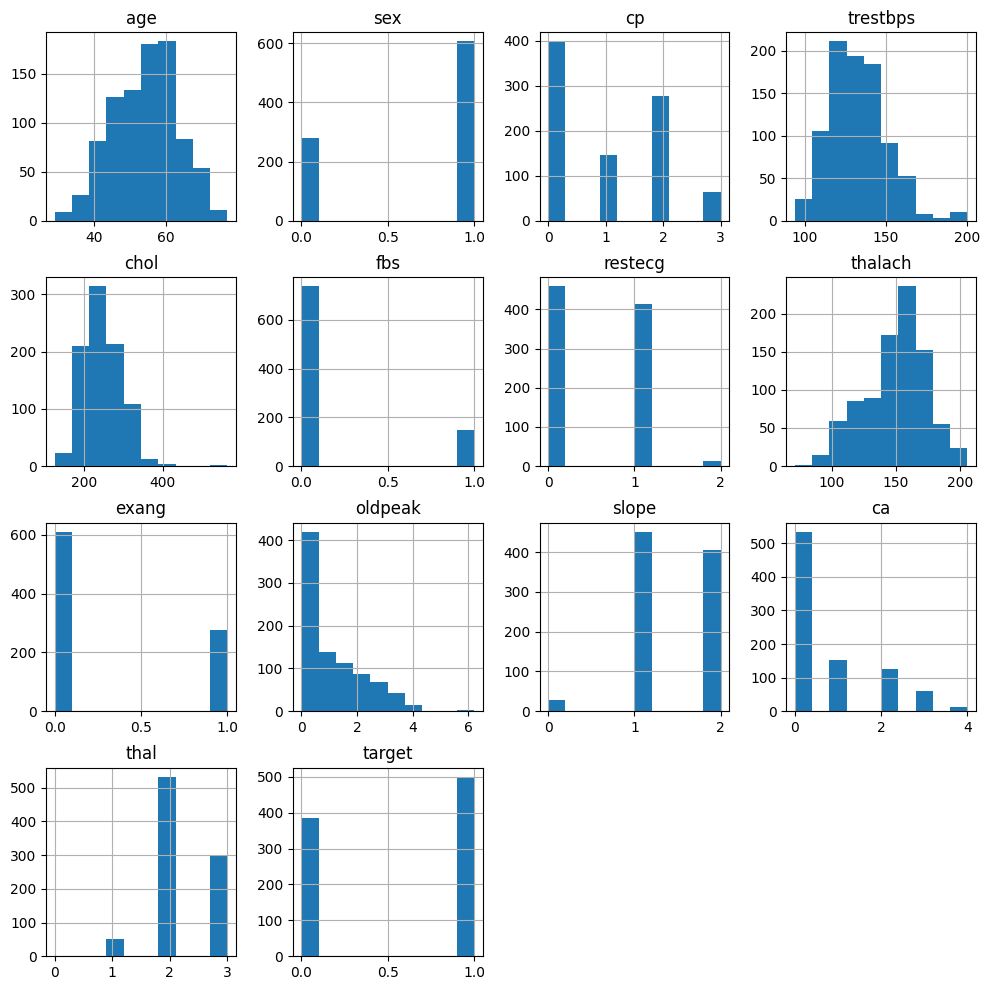

In [6]:
# Plot histograms for each feature
df.hist(figsize=(12, 12))
plt.show()

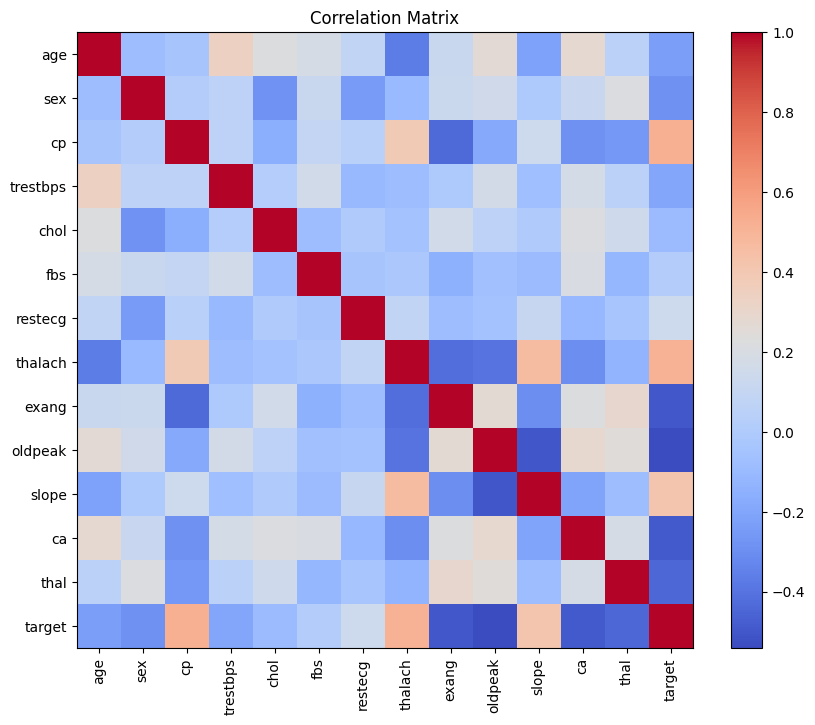

In [7]:
# Plot correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title('Correlation Matrix')
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

# Fill missing values if any
df.fillna(df.mean(), inplace=True)

# Standardize the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df.drop('target', axis=1))

# Create a new DataFrame with the scaled features
df_scaled = pd.DataFrame(scaled_features, columns=df.columns[:-1])
df_scaled['target'] = df['target']

In [9]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X = df_scaled.drop('target', axis=1)
y = df_scaled['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
from sklearn.linear_model import LogisticRegression

# Train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Predict on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f'Precision: {precision}')
print(f'Recall: {recall}')
print(f'F1 Score: {f1}')
print('Confusion Matrix:')
print(conf_matrix)

Precision: 0.9626168224299065
Recall: 0.9716981132075472
F1 Score: 0.9671361502347418
Confusion Matrix:
[[ 68   4]
 [  3 103]]


## 3.1.2. Open discussion questions

3.1.2.1 Relationship between age and heart disease likelihood

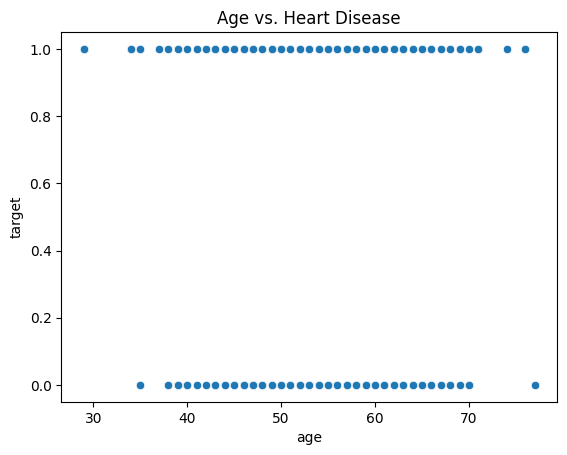

Correlation between age and heart disease: -0.232576048903785


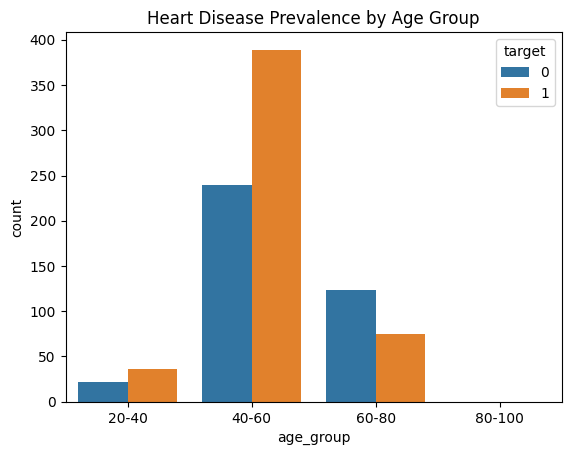

In [13]:
# Scatter plot of age vs. heart disease
sns.scatterplot(x='age', y='target', data=df)
plt.title('Age vs. Heart Disease')
plt.show()

# Calculate correlation coefficient
correlation = df['age'].corr(df['target'])
print(f"Correlation between age and heart disease: {correlation}")

# Explore for different age groups
# For example, create age groups and compare heart disease prevalence
df['age_group'] = pd.cut(df['age'], bins=[20, 40, 60, 80, 100], labels=['20-40', '40-60', '60-80', '80-100'])
sns.countplot(x='age_group', hue='target', data=df)
plt.title('Heart Disease Prevalence by Age Group')
plt.show()

By analyzing the scatter plot, correlation coefficient, and age group comparisons, we can draw conclusions about the relationship between age and the likelihood of heart disease in this dataset. A positive correlation would suggest that as age increases, the likelihood of heart disease also tends to increase. Exploring different age groups can reveal if certain age ranges are more susceptible to heart disease.

3.1.2.2 Vital signs comparison between patients with and without heart disease

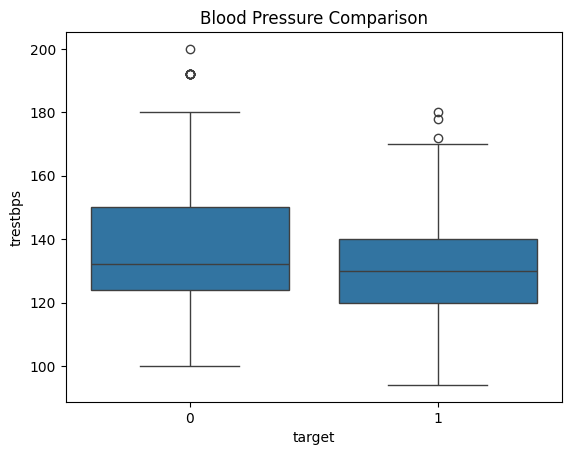

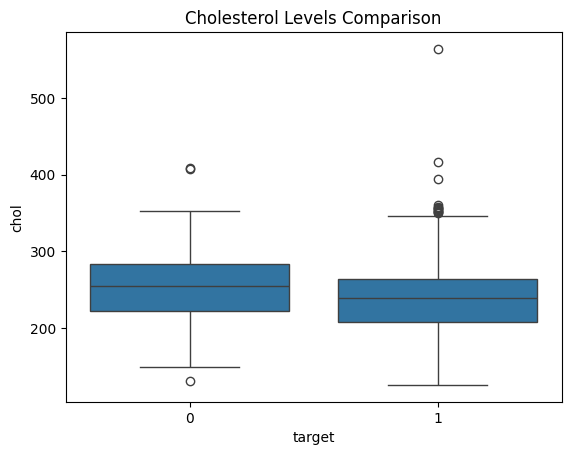

       trestbps                                                            \
          count        mean        std    min    25%    50%    75%    max   
target                                                                      
0         386.0  135.841969  18.456081  100.0  124.0  132.0  150.0  200.0   
1         500.0  129.242000  14.805060   94.0  120.0  130.0  140.0  180.0   

         chol                                                            
        count        mean        std    min    25%    50%    75%    max  
target                                                                   
0       386.0  252.502591  45.472026  131.0  223.0  255.0  284.0  409.0  
1       500.0  243.634000  48.199527  126.0  208.0  239.0  264.0  564.0  


In [17]:
# Box plots for blood pressure and cholesterol levels
sns.boxplot(x='target', y='trestbps', data=df)
plt.title('Blood Pressure Comparison')
plt.show()

sns.boxplot(x='target', y='chol', data=df)
plt.title('Cholesterol Levels Comparison')
plt.show()

# Descriptive statistics for vital signs by heart disease status
print(df.groupby('target')[['trestbps', 'chol']].describe())

By comparing the box plots and descriptive statistics, we can identify differences in vital signs between patients with and without heart disease. For example, higher blood pressure or cholesterol levels in the heart disease group might indicate a potential risk factor.

3.1.2.3 High fasting blood sugar as a risk factor

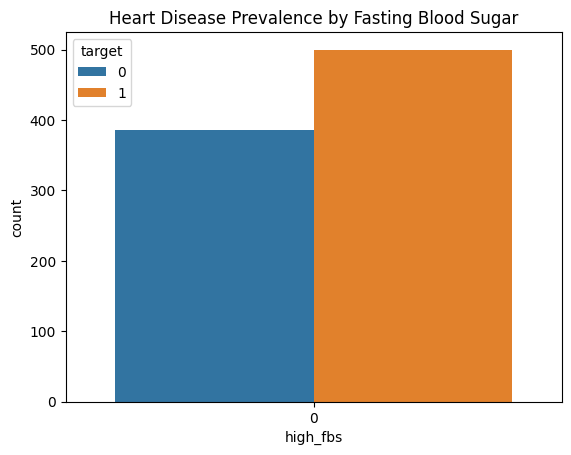

In [18]:
# Create a new column for high fasting blood sugar (fbs > 120)
df['high_fbs'] = (df['fbs'] > 120).astype(int)

# Compare heart disease prevalence for high and normal fbs
sns.countplot(x='high_fbs', hue='target', data=df)
plt.title('Heart Disease Prevalence by Fasting Blood Sugar')
plt.show()

By comparing the prevalence of heart disease in patients with and without high fasting blood sugar, we can assess if high fbs appears to be a risk factor. A higher prevalence of heart disease in the high fbs group would suggest a potential association.

3.1.2.4 Most important features for predicting heart disease

In [19]:
# Feature importance from Logistic Regression model
importance = model.coef_[0]
feature_names = X.columns
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print(feature_importance)

     Feature  Importance
2         cp    1.556773
10     slope    0.594715
7    thalach    0.579399
6    restecg    0.152299
5        fbs    0.117320
0        age    0.002571
4       chol   -0.032959
3   trestbps   -0.561689
8      exang   -0.564648
12      thal   -0.884062
1        sex   -1.006558
11        ca   -1.297840
9    oldpeak   -1.356291


By analyzing the feature importance, we can identify the features that have the strongest impact on predicting heart disease. This information can be valuable for understanding the underlying factors contributing to heart disease and for building more effective predictive models.

## Assignment 3.2 *(3 points)*: Logistic Regression - CIFAR 10 SMALL dataset

This example demonstrates how to build a logistic regression model to recognize objects in CIFAR 10 dataset.

In this assignment, you will have to:
- 3.2.1 (Done) Load the dataset.
- 3.2.2 *(1 point)* Preprocess and normalize the images.
- 3.2.3 *(1 point)* Construct, train, and evaluate a multinomial logistic regression model for CIFAR 10 SMALL image classification.
- 3.2.4 *(1 point)* Assess the model’s performance on the test set. Keep in mind that low accuracy is acceptable due to the complexity of the data and the limited capacity of logistic regression.

The dataset you will be working on is CIFAR 10 SMALL (https://www.openml.org/d/40926) which consists of 20,000 32x32 colour images in 10 classes, with 2,000 images per class. There are 14,000 training images and 6,000 test images. Here follows the ten object classes:
* airplane
* automobile
* bird
* cat
* deer
* dog
* frog
* horse
* ship
* truck

Here follows some data samples in the dataset:

![alt text](https://production-media.paperswithcode.com/datasets/4fdf2b82-2bc3-4f97-ba51-400322b228b1.png)

In [20]:
# Import necessary libraries
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [21]:
# Load the CIFAR 10 SMALL dataset from openml
# OpenML is an open platform for sharing datasets, algorithms, and experiments
cifar_10_small = fetch_openml('cifar_10_small', version=1, parser='auto')

In [22]:
# Separate data into features X and labels y, then convert to numpy arrays
X = cifar_10_small['data'].to_numpy()
y = cifar_10_small['target'].to_numpy()

print("Feature shape: " + str(X.shape))
print("Label shape: " + str(y.shape))

class_names = [
    'airplane',   # Label: 0
    'automobile', # Label: 1
    'bird',       # Label: 2
    'cat',        # Label: 3
    'deer',       # Label: 4
    'dog',        # Label: 5
    'frog',       # Label: 6
    'horse',      # Label: 7
    'ship',       # Label: 8
    'truck'       # Label: 9
]

Feature shape: (20000, 3072)
Label shape: (20000,)


Label: dog


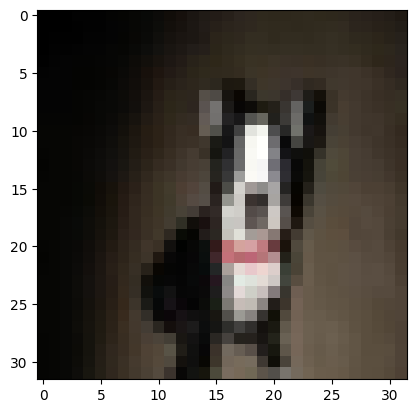

In [23]:
# Print a sample of the dataset
print("Label: " + class_names[int(y[198])])
plt.imshow(X[198].reshape(3,32,32).transpose([1,2,0])) # The nature of the data requires this restructuring.

Label: automobile


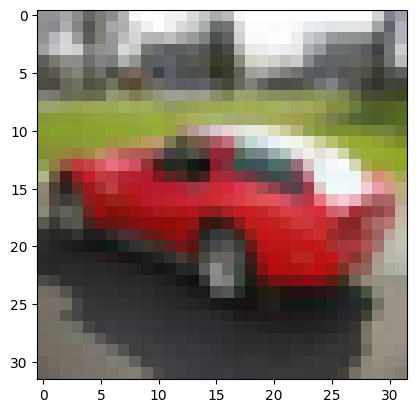

In [25]:
# Print a sample of the dataset
print("Label: " + class_names[int(y[255])])
plt.imshow(X[255].reshape(3,32,32).transpose([1,2,0])) # The nature of the data requires this restructure.

In [26]:
# Split the dataset into training and testing sets (using 70% for training and 30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=17)

In [27]:
# Preprocess and normalize the images
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# Construct, train, and evaluate the model
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=100)
model.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(multi_class='multinomial')

In [31]:
# Assess the model's performance
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.34983333333333333
